# Aumento del contrasto di un'immagine a basso contrasto



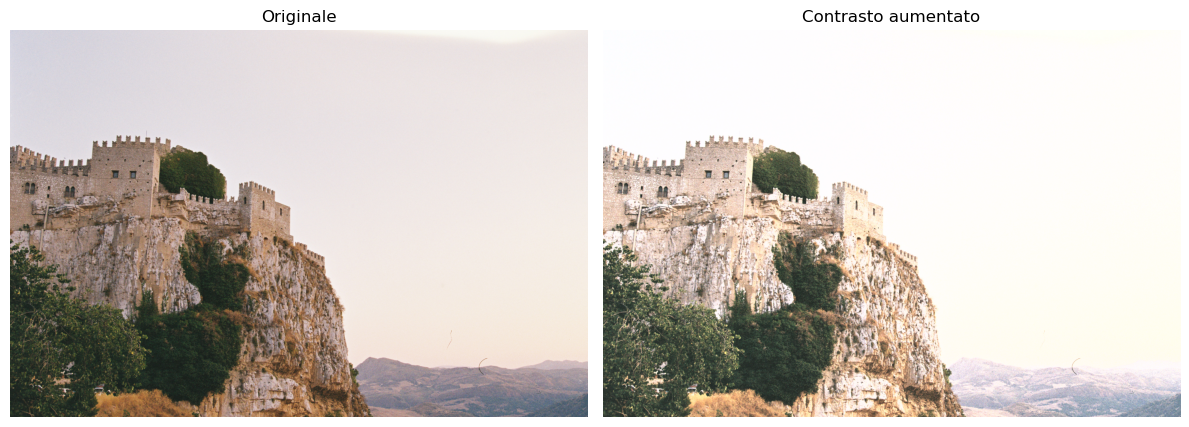

In [1]:
import cv2
import numpy as np

import matplotlib.pyplot as plt

# Caricamento immagine 
im_low = cv2.imread('low_contrast.jpg')

# Conversione da BGR, formato OpenCv, a LAB
lab = cv2.cvtColor(im_low, cv2.COLOR_BGR2LAB)

# Conversione a float per evitare overflow durante la moltiplicazione
lab = lab.astype(np.float32)

# Aumento del contrasto / luminosita' sul canale L
lab[:, :, 0] *= 1.5

#Clipping dei valori nell'intervallo valido [0,255]

l_channel = lab[:,:,0]
# Clip

l_channel[l_channel>255] = 255

# Riconversione a uint8
lab = lab.astype(np.uint8)

# Conversione da LAB a BGR
im_high = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

# Visualizzazione delle immagini

"""cv2.imshow("im_low", im_low)
cv2.imshow("im_high", im_high)
cv2.waitKey(0)
cv2.destroyAllWindows()"""

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,5)) # 1 riga 2 colonne

ax1.imshow(cv2.cvtColor(im_low, cv2.COLOR_BGR2RGB))
ax1.axis('off')
ax1.set_title('Originale')

ax2.imshow(cv2.cvtColor(im_high, cv2.COLOR_BGR2RGB))
ax2.axis('off')
ax2.set_title('Contrasto aumentato')

plt.tight_layout()
plt.show()

Il contrasto viene aumentato moltiplicandolo per un fatto maggiore di uno; effettuata l'operazione, prima di riconvertire l'immagine nel formato BGR, viene effettuato il *clipping* per fare in modo che i valori della matrice L rientrino nello spazio [0,255].

In sintesi, il codice realizza un aumento del contrasto agendo principalmente sulla componente luminosa dell’immagine, preservando meglio la componente cromatica rispetto a una modifica diretta dei canali RGB/BGR.

### Filtro medio generico su immagine a colori

Il concetto è costruire un **kernel** 11x11 con coefficienti tutti uguali, normalizzati in maniera tale che la loro somma faccia 1, successivamente lo si applica all'immagine con `cv2.filter2D`

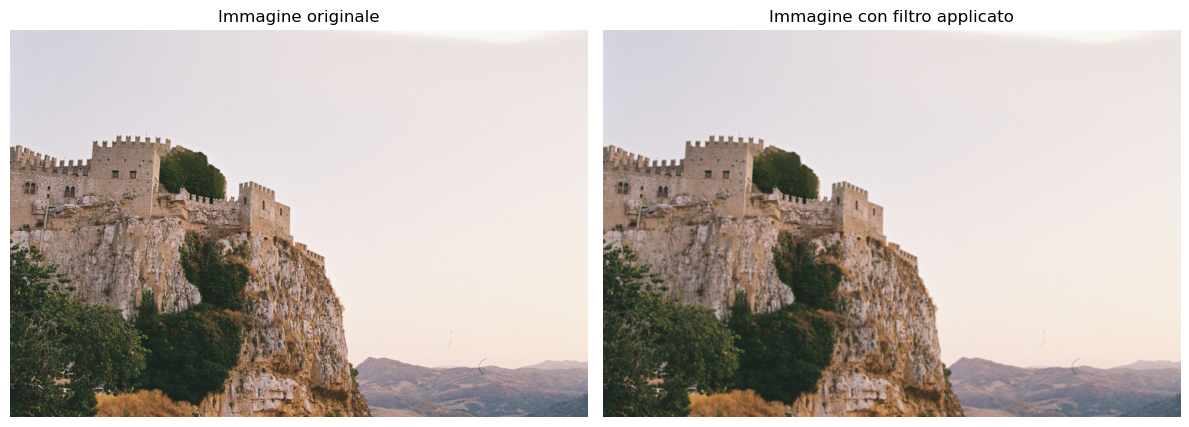

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

im_low = cv2.imread("low_contrast.jpg")

# Kernel medio 11x11
kernel = (1 / 121) * np.ones((11,11), np.float32)

# Applicazione del filtro all'immagine 
# ddepth=-1 mantiene la stessa profondità dell'immagine di input

avg = cv2.filter2D(src=im_low, ddepth=-1, kernel=kernel)

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12, 5))

ax1.imshow(cv2.cvtColor(im_low, cv2.COLOR_BGR2RGB))
ax1.set_title("Immagine originale")
ax1.axis('off')


ax2.imshow(cv2.cvtColor(avg, cv2.COLOR_BGR2RGB))
ax2.set_title("Immagine con filtro applicato")
ax2.axis('off')

plt.tight_layout()
plt.show()
